In [71]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [72]:
import os
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.gridspec import GridSpec
import matplotlib

import sys

sys.path.append("../src")

import jax
import jax.numpy as jnp

import netket as nk
import numpy as np

from netket.operator.spin import sigmax, sigmaz
from metropolis import LocalDoubleFlipRule
from netket.experimental.dynamics import RK45,Heun
from callbacks import (
    get_acceptance_rate_callback,
    get_umbrella_monitor_callback,
    get_tdvp_monitor_callback,
    get_parameter_save_callback,
)
from logger import Logger

from schmitt_tdvp_bridge import TDVPSchmittBridge
from schmitt_tdvp import TDVPSchmitt

import argparse
import numpy as np

from gaussian_state import GaussianState
from tfim_exact_majorana import run_ed


In [164]:
import netket as nk
import flax.linen as nn
import jax.numpy as jnp


class TwoQubitThetaState(nn.Module):
    """
    psi(theta1, theta2):
      |00> -> theta1
      |01> -> theta2
      |10> -> theta3
      |11> -> theta4
    """

    theta3_0: complex = 0.0 + 0.0j
    theta4_0: complex = 0.0 + 0.0j

    @nn.compact
    def __call__(self, x_in):
        # x_in: shape (batch, 2) with entries typically in {-1, +1}
        theta3 = self.param("theta3", nn.initializers.constant(self.theta3_0, dtype=complex), ())
        theta4 = self.param("theta4", nn.initializers.constant(self.theta4_0, dtype=complex), ())

        x = jnp.asarray(x_in)
        assert x.shape[-1] == 2, "This model is for 2 qubits (N=2)."

        # Map spin values {-1,+1} -> bits {0,1}
        b = (x == 1).astype(jnp.int32)  # (batch,2)
        idx = (b[..., 0] << 1) + b[..., 1]  # 0..3 for 00,01,10,11
        # amplitudes in order [00, 01, 10, 11]
        amps = jnp.array([1., theta3, theta4, 1.], dtype=complex)
        amp = amps[idx]

        return jnp.log(amp)


hilbert = nk.hilbert.Spin(s=1 / 2, N=2)


def get_vstate(n_samples=4096, seed=0):
    sampler = nk.sampler.MetropolisLocal(hilbert, n_chains=n_samples)

    model = TwoQubitThetaState(theta3_0=(1.), theta4_0=(1.0 ))

    vstate = nk.vqs.MCState(
        sampler=sampler,
        model=model,
        n_samples=n_samples,
        seed=seed,
    )
    vstate.sample()
    return vstate


In [165]:
fields_to_track = (
    ("t", "values"),
    ("dt", "values"),
    ("Generator", "Mean"),
    ("Generator", "Variance"),
    ("observable", "Variance"),
    ("observable", "Mean"),
    ("r_squared", "values"),
    # Umbrella/bridge monitoring fields
    ("ess_bridge", "values"),
    ("snr_min", "values"),
    ("snr_10p", "values"),
    ("snr_med", "values"),
    ("snrF_min", "values"),
    ("snrF_med", "values"),
    ("q_bridge", "values"),
    # Per-step SNRs from OVar
    ("snr", "values"),
    ("snr_F", "values"),
    ("acceptance_rate", "values")
)

hamiltonian = nk.operator.spin.sigmax(hilbert, 0) @ nk.operator.spin.sigmax(hilbert, 1)
observable = nk.operator.spin.sigmaz(hilbert, 1)

def measure_sigma_z(step, log, driver):
    log['observable'] = driver.state.expect(observable)
    print(log['observable'])
    return True


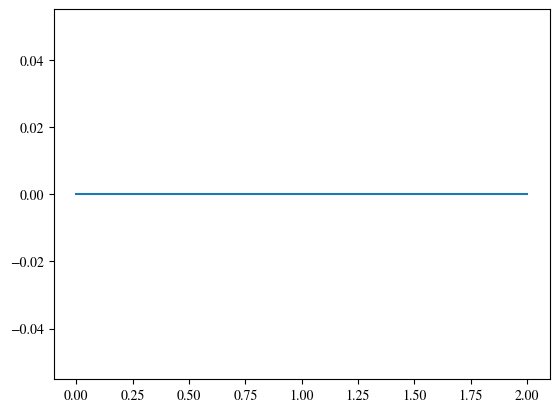

: 

In [ ]:
import qutip as qt

# Get the Hamiltonian matrix from netket
H_matrix = hamiltonian.to_sparse()

# Convert to QuTiP Qobj
H_qutip = qt.Qobj(H_matrix)
vstate = get_vstate(2**10)
# Get initial state from vstate
psi0_array = vstate.to_array()
psi0_qutip = qt.Qobj(psi0_array)
psi0_qutip = psi0_qutip.unit()  # Normalize

# Create total magnetization operator (sum of Z_i)
# Convert netket operator to matrix
observable_mat = observable.to_dense()
# Convert to QuTiP
O_total_qutip = qt.Qobj(observable_mat)

# Time evolution parameters
T = 2.
times_exact = np.linspace(0.0, T, 100)

# Evolve the state and calculate expectation values
magnetizations_exact = []
for t in times_exact:
    # Evolve state
    psi_t = (-1j * H_qutip * t).expm() * psi0_qutip
    # Calculate expectation value
    mag = qt.expect(O_total_qutip, psi_t)
    magnetizations_exact.append(mag)
plt.plot(times_exact, magnetizations_exact)


In [161]:
from schmitt_tdvp_bridge import TDVPSchmittBridge
from schmitt_tdvp import TDVPSchmitt
from schmitt_tdvp_randomized_bridge import TDVPSchmittRandomizedBridge

def run(q, n_samples_tvmc, randomized=False):
    T = 2.
    save_times = np.linspace(0.0, T, 20)
    exp_name = f"bridge_{n_samples_tvmc}_q_{q:1.2f}{'_randomized' if randomized else ''}"
    # Make sure we always start with the same state in notebook

    vstate = get_vstate(n_samples_tvmc)
    save_path = f"./data/SUPPORT_COLLAPSE/{exp_name}/"
    if not os.path.exists(save_path):
        os.makedirs(save_path)

    logger = Logger(path=save_path, fields=fields_to_track)
    restored = logger.restore()
    
    if restored and logger.done:
        print("Data exists")
        return
    callbacks = [ ]
    callbacks.append(measure_sigma_z)
    callbacks.append(get_parameter_save_callback(save_times, logger))
    # callbacks.append(get_acceptance_rate_callback())
    if q==0:
        tdvp_monitor_callback = get_tdvp_monitor_callback(save_times, save_path)
    else:
        tdvp_monitor_callback = get_umbrella_monitor_callback(save_times, save_path)
        
    callbacks.append(tdvp_monitor_callback)

    # integrator = RK45(1e-5, adaptive=True, dt_limits=(1e-5, 1e-2))
    integrator = Heun(1e-3)
    tvmc_kwargs = {}
    # thermalize
    for i in range(100):
        vstate.sample()

    if jnp.isclose(q, 0):
        driver = TDVPSchmitt(
            hamiltonian,
            vstate,
            integrator,
            t0=0,
            holomorphic=False,
            snr_atol=2,
            rcond=1e-14,
            rcond_smooth=1e-10,
            **tvmc_kwargs,
        )
    else:
        if randomized:
            print("randomized")
            driver = TDVPSchmittRandomizedBridge(
                hamiltonian,
                vstate,
                integrator,
                t0=0,
                q=q,
                flip_prob=0.5,
                holomorphic=False,
                snr_atol=2,
                rcond=1e-14,
                rcond_smooth=1e-10,
                **tvmc_kwargs,
            )
        else:
            driver = TDVPSchmittBridge(
                hamiltonian,
                vstate,
                integrator,
                t0=0,
                q=q,
                holomorphic=False,
                snr_atol=2,
                rcond=1e-14,
                rcond_smooth=1e-10,
                diagonal_mels=False,
                **tvmc_kwargs,
            )

    driver.run(
        T,
        out=logger,
        callback = callbacks,
        show_progress=True,
        timeit=True,
    )
    logger.flush(done=True)
run(0.0, 2**12)
# run(0.2, 2**12)
# run(0.2, 2**12, randomized=True)

  0%|          | 0.00/2.00 [00:00<?, ?it/s, n=0]


KeyboardInterrupt: 

Restored: True
Restored: True
File not found
Restored: False


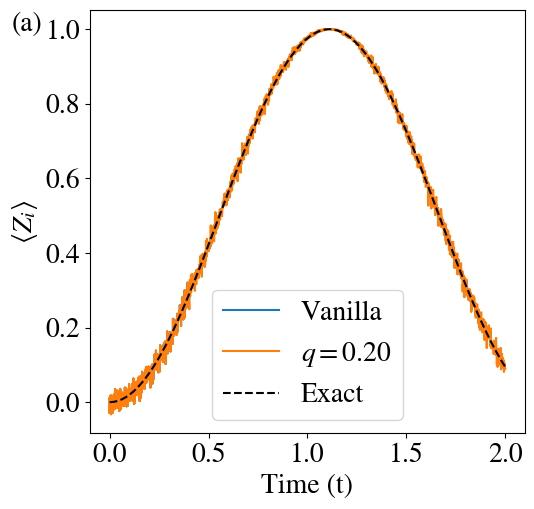

In [133]:
matplotlib.rcParams["mathtext.fontset"] = "stix"
matplotlib.rcParams["font.family"] = "STIXGeneral"
n_samples_tvmc = 2**12
fig = plt.figure(figsize=(5.8, 5.5))
gs = GridSpec(1, 1, figure=fig, wspace=0.45, hspace=0.33)
ax_z = fig.add_subplot(gs[0])

# Add whitespace to the left of the plot
fig.subplots_adjust(left=0.15)

for q in [0.0, 0.2]:
    if q>0.0:
        for randomized in [True, False]:
            exp_name = f"bridge_{n_samples_tvmc}_q_{q:1.2f}{'_randomized' if randomized else ''}"
            save_path = f"./data/SUPPORT_COLLAPSE/{exp_name}/"
            logger = Logger(path=save_path, fields=fields_to_track)
            restored= logger.restore()
            print("Restored:", restored)
            if not restored:
                continue
            ax_z.plot(
                logger.data["t"]["values"],
                np.array(logger.data["observable"]["Mean"]).real,
                label="Vanilla" if q == 0 else f"$q=${q:1.2f}",
            )
    else:
        exp_name = f"bridge_{n_samples_tvmc}_q_{q:1.2f}"
        save_path = f"./data/SUPPORT_COLLAPSE/{exp_name}/"
        logger = Logger(path=save_path, fields=fields_to_track)
        restored= logger.restore()
        print("Restored:", restored)
        if not restored:
            continue
        ax_z.plot(
            logger.data["t"]["values"],
            np.array(logger.data["observable"]["Mean"]).real,
            label="Vanilla" if q == 0 else f"$q=${q:1.2f}",
        )

ax_z.plot(
    times_exact, magnetizations_exact, label="Exact", linestyle="--", color="black"
)
loc_x = -0.18
loc_y = 0.95
ax_z.annotate("(a)", xy=(loc_x, loc_y), xycoords="axes fraction", fontsize=20)
ax_z.set_xlabel("Time (t)", fontsize=20)
ax_z.set_ylabel(r"$\langle Z_i \rangle$", fontsize=20)
ax_z.legend(fontsize=20)
ax_z.tick_params(labelsize=20)
fig.savefig("Fig4a.pdf",bbox_inches="tight", pad_inches=0.01)